#  Air quality and pollution assessment

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [2]:
df=pd.read_csv('updated_pollution_dataset.csv')
df.head()

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319,Moderate
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611,Moderate
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619,Moderate
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551,Good
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303,Good


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Temperature                    5000 non-null   float64
 1   Humidity                       5000 non-null   float64
 2   PM2.5                          5000 non-null   float64
 3   PM10                           5000 non-null   float64
 4   NO2                            5000 non-null   float64
 5   SO2                            5000 non-null   float64
 6   CO                             5000 non-null   float64
 7   Proximity_to_Industrial_Areas  5000 non-null   float64
 8   Population_Density             5000 non-null   int64  
 9   Air Quality                    5000 non-null   object 
dtypes: float64(8), int64(1), object(1)
memory usage: 390.8+ KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Temperature,5000.0,30.029020,6.720661,13.40,25.10,29.00,34.000,58.60
Humidity,5000.0,70.056120,15.863577,36.00,58.30,69.80,80.300,128.10
PM2.5,5000.0,20.142140,24.554546,0.00,4.60,12.00,26.100,295.00
PM10,5000.0,30.218360,27.349199,-0.20,12.30,21.70,38.100,315.80
NO2,5000.0,26.412100,8.895356,7.40,20.10,25.30,31.900,64.90
SO2,5000.0,10.014820,6.750303,-6.20,5.10,8.00,13.725,44.90
CO,5000.0,1.500354,0.546027,0.65,1.03,1.41,1.840,3.72
Proximity_to_Industrial_Areas,5000.0,8.425400,3.610944,2.50,5.40,7.90,11.100,25.80
Population_Density,5000.0,497.423800,152.754084,188.00,381.00,494.00,600.000,957.00


In [6]:
df.isnull().sum()

Temperature                      0
Humidity                         0
PM2.5                            0
PM10                             0
NO2                              0
SO2                              0
CO                               0
Proximity_to_Industrial_Areas    0
Population_Density               0
Air Quality                      0
dtype: int64

In [7]:
df.dtypes

Temperature                      float64
Humidity                         float64
PM2.5                            float64
PM10                             float64
NO2                              float64
SO2                              float64
CO                               float64
Proximity_to_Industrial_Areas    float64
Population_Density                 int64
Air Quality                       object
dtype: object

In [8]:
df.duplicated().sum()

0

In [9]:
df['Air Quality'].value_counts()

Air Quality
Good         2000
Moderate     1500
Poor         1000
Hazardous     500
Name: count, dtype: int64

In [10]:
df = df.rename(columns={'PM2.5':'PM25'})
df.head()
#  variable name cannot contain dot 

,Temperature,Humidity,PM25,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319,Moderate
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611,Moderate
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619,Moderate
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551,Good
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303,Good


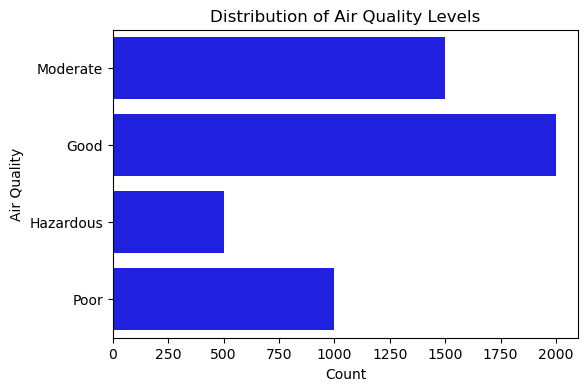

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(y=df['Air Quality'],color='blue')
plt.title("Distribution of Air Quality Levels")
plt.xlabel("Count")
plt.ylabel("Air Quality")
plt.show()

In [11]:
#  encode target variable

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Air Quality'] = le.fit_transform(df['Air Quality'])
df.head()

,Temperature,Humidity,PM25,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319,2
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611,2
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619,2
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551,0
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303,0


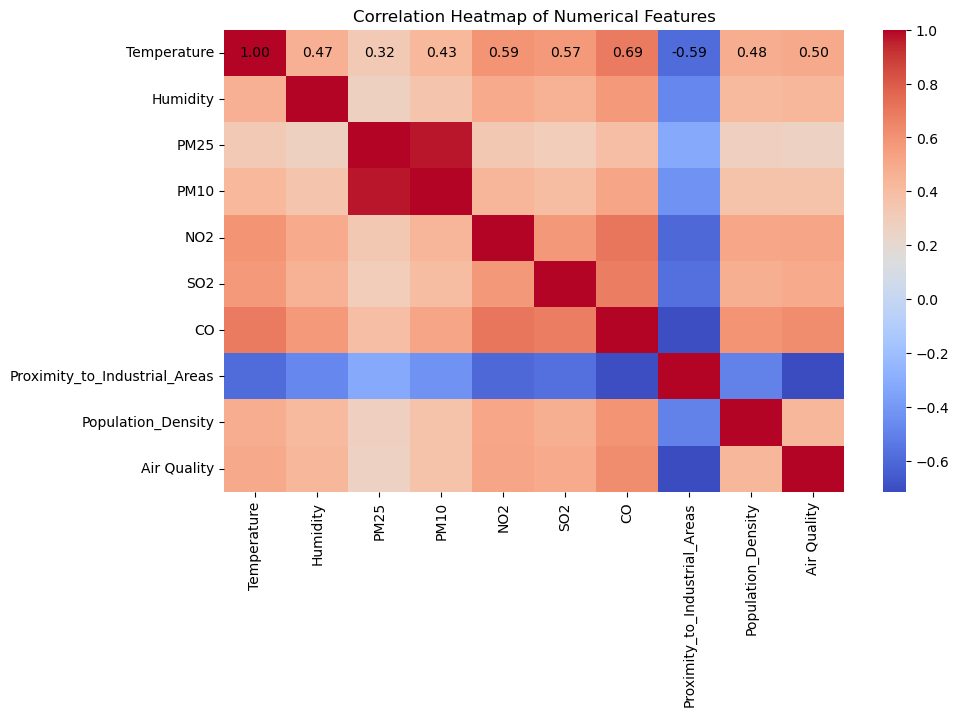

In [12]:
#  correlation heat map
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',fmt='.2f',annot_kws={'size':10,"color":"black"})
plt.title("Correlation Heatmap of Numerical Features")
plt.show() 

In [13]:
# feature and target
x = df.drop('Air Quality',axis=1)
y = df['Air Quality']

In [14]:
x.head()

,Temperature,Humidity,PM25,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303


In [15]:
y.head()

0    2
1    2
2    2
3    0
4    0
Name: Air Quality, dtype: int32

In [16]:
#  train_test_split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [17]:
#  feacture scaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [19]:
#  logistic regression

from sklearn.linear_model import LogisticRegression
LRmodel = LogisticRegression(max_iter=1000)
LRmodel.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [20]:
y_pred=LRmodel.predict(x_test)

In [21]:
acc= accuracy_score(y_test,y_pred)
acc

0.947

In [21]:
# Decision tree
from sklearn.tree import DecisionTreeClassifier
DTmodel = DecisionTreeClassifier()
DTmodel.fit(x_train,y_train)

DecisionTreeClassifier()

In [23]:
y_pred= DTmodel.predict(x_test)

In [28]:
acc= accuracy_score(y_test,y_pred)
acc

0.922

In [24]:
#  Random forest
from sklearn.ensemble import RandomForestClassifier
RFmodel=RandomForestClassifier()
RFmodel.fit(x_train,y_train)

RandomForestClassifier()

In [25]:
RFy_pred=RFmodel.predict(x_test)

In [26]:
acc= accuracy_score(y_test,RFy_pred)
acc

0.959

In [27]:
print("---- Testing Scores ----")
print("Accuracy Score:" ,accuracy_score(y_test,RFy_pred))
print("Classification Report:" ,classification_report(y_test,RFy_pred))
print("Confusion Matrix:", confusion_matrix(y_test,RFy_pred))

---- Testing Scores ----
Accuracy Score: 0.959
Classification Report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00       409
           1       0.92      0.89      0.90       111
           2       0.97      0.96      0.97       294
           3       0.88      0.90      0.89       186

    accuracy                           0.96      1000
   macro avg       0.94      0.94      0.94      1000
weighted avg       0.96      0.96      0.96      1000

Confusion Matrix: [[409   0   0   0]
 [  0  99   0  12]
 [  0   0 283  11]
 [  0   9   9 168]]


In [22]:
# predict for new data
new_data= [[25.2,50,12.5,33.5,20,10,15,50.5,553]]

new_data=scaler.transform(new_data)
prediction= RFmodel.predict(new_data)
print('predicted air quality:', prediction)


predicted air quality: [3]


C:\Users\nayan\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [23]:
# convert prediction to original label

prediction_label=le.inverse_transform(prediction)
print('predicted air quality:',prediction_label)

predicted air quality: ['Poor']


In [39]:
#  support vector machine
from sklearn.svm import SVC
SVCmodel=SVC()
SVCmodel.fit(x_train,y_train)

SVC()

In [40]:
y_pred=SVCmodel.predict(x_test)

In [41]:
acc=accuracy_score(y_test,y_pred)
acc

0.942

In [42]:
#  k-nearest neighbors
from sklearn.neighbors import KNeighborsClassifier
KNmodel= KNeighborsClassifier()
KNmodel.fit(x_train,y_train)

KNeighborsClassifier()

In [43]:
y_pred=KNmodel.predict(x_test)

In [45]:
acc=accuracy_score(y_test,y_pred)
acc

0.935

In [46]:
#  Naive bayes
from sklearn.naive_bayes import GaussianNB
NBmodel = GaussianNB()
NBmodel. fit(x_train,y_train)

GaussianNB()

In [47]:
y_pred=NBmodel.predict(x_test)

In [48]:
acc= accuracy_score(y_test,y_pred)
acc

0.926

In [ ]:
#  TOP 3 MODELS
1- Random Forest classifier  95.9
2- Logistic Regression       94.7
3- Support Vector Machine    94.2                 

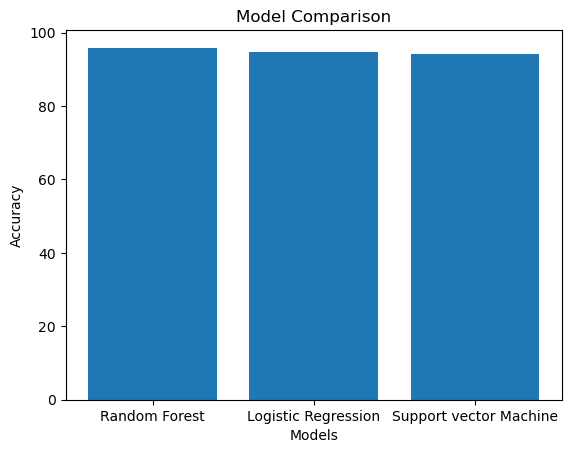

In [55]:
# Model Comparison
model=['Random Forest','Logistic Regression','Support vector Machine']
accuracy=[95.9,94.7,94.2]

plt.figure()
plt.bar(model,accuracy)
plt.title('Model Comparison')
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
0- good
1- hazardous
2- moderate
3- poor

In [28]:
!pip install gradio

In [29]:
import gradio as gr

In [30]:
def predict_Air_Quality(Temperature, Humidity, PM25, PM10, NO2, SO2, CO, Proximity_to_Industrial_Areas, Population_Density):

    data = [[Temperature, Humidity, PM25, PM10, NO2, SO2, CO,
             Proximity_to_Industrial_Areas, Population_Density]]

    prediction = RFmodel.predict(data)

    label_map = {0: "Good", 1: "Hazardous", 2: "Moderate", 3: "Poor"}

    return label_map[prediction[0]]

In [31]:
interface = gr.Interface(
    fn=predict_Air_Quality,
    inputs=[
        gr.Number(label="Temperature"),
        gr.Number(label="Humidity"),
        gr.Number(label="PM2.5"),
        gr.Number(label="PM10"),
        gr.Number(label="NO2"),
        gr.Number(label="SO2"),
        gr.Number(label="CO"),
        gr.Number(label="Proximity to Industrial Areas"),
        gr.Number(label="Population Density")
    ],
    outputs=gr.Label(),
    title="Air Quality Prediction",
    description="Enter environmental values to predict air quality"
)

In [32]:
interface.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


## 